✓ Imports ready
BPSK        bits/sym=1  M= 2  avg_power=1.000000  (should be 1.0)
QPSK        bits/sym=2  M= 4  avg_power=1.000000  (should be 1.0)
16-QAM      bits/sym=4  M=16  avg_power=1.000000  (should be 1.0)
64-QAM      bits/sym=6  M=64  avg_power=1.000000  (should be 1.0)

  OFDM System Configuration  (802.11a-style)
  FFT size          : 64 points
  Cyclic prefix     : 16 samples  (20% overhead)
  Symbol duration   : 80 samples
────────────────────────────────────────────────────
  Total subcarriers : 64
  Active            : 52
  ├── Data          : 48
  └── Pilots        : 4  [7, 21, 43, 57]
  DC + Guard        : 12
────────────────────────────────────────────────────
  BPSK        →    48 bits/OFDM symbol  (48 × 1)
  QPSK        →    96 bits/OFDM symbol  (48 × 2)
  16-QAM      →   192 bits/OFDM symbol  (48 × 4)
  64-QAM      →   288 bits/OFDM symbol  (48 × 6)


  OFDM System Configuration  (802.11a-style)
  FFT size          : 64 points
  Cyclic prefix     : 16 samples  (20%

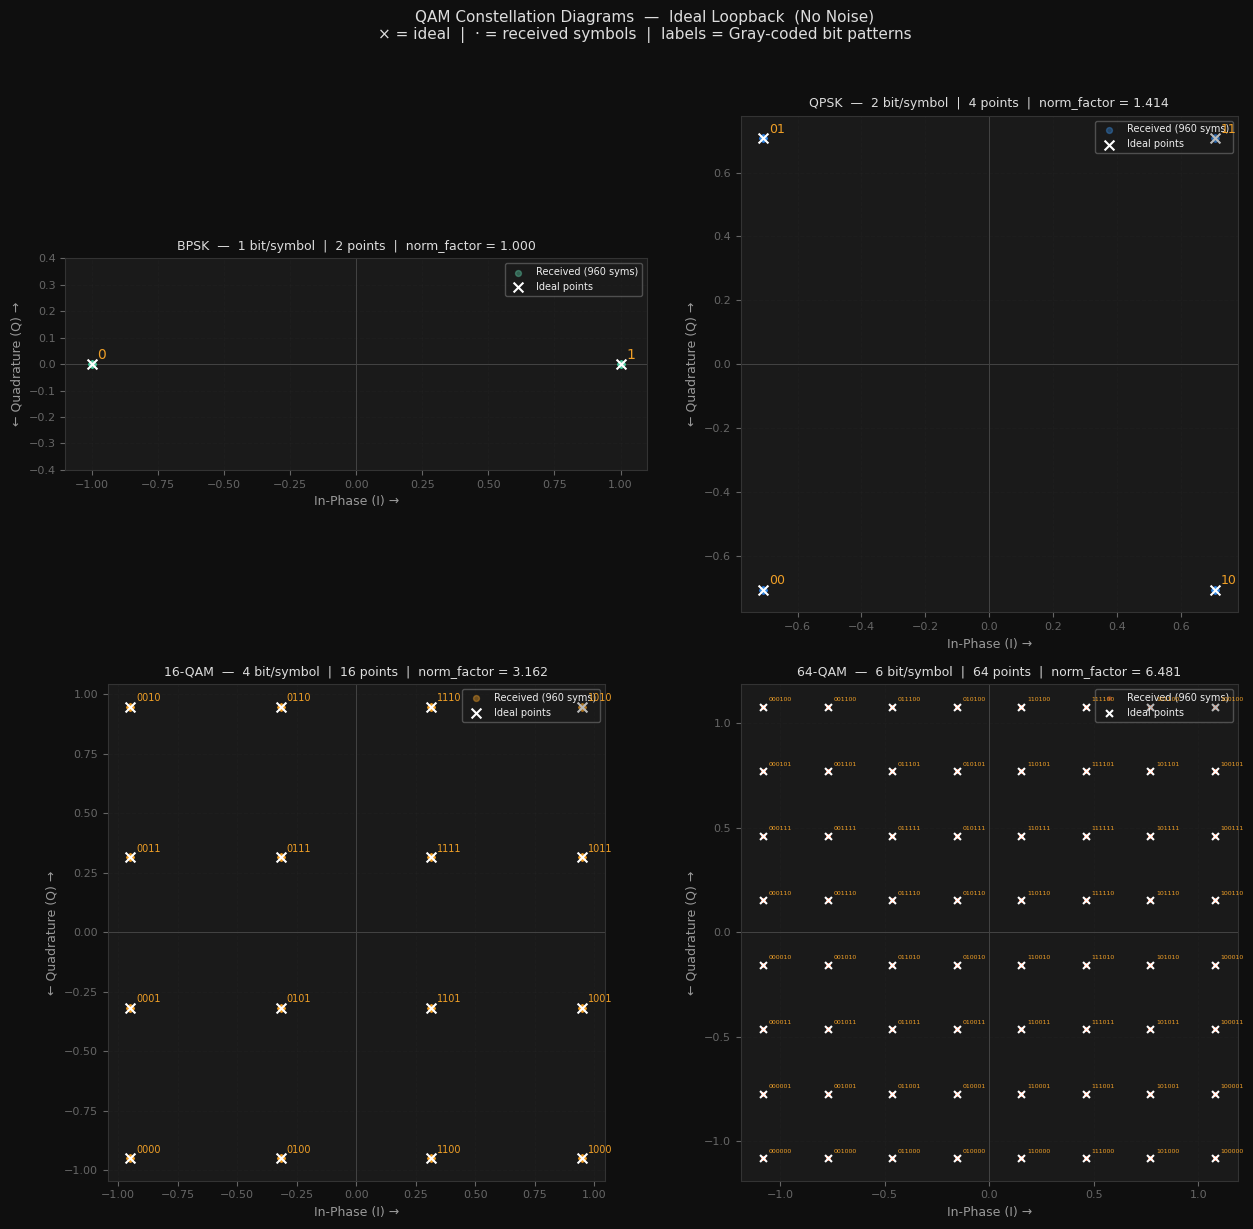

✓ Saved → constellations.png


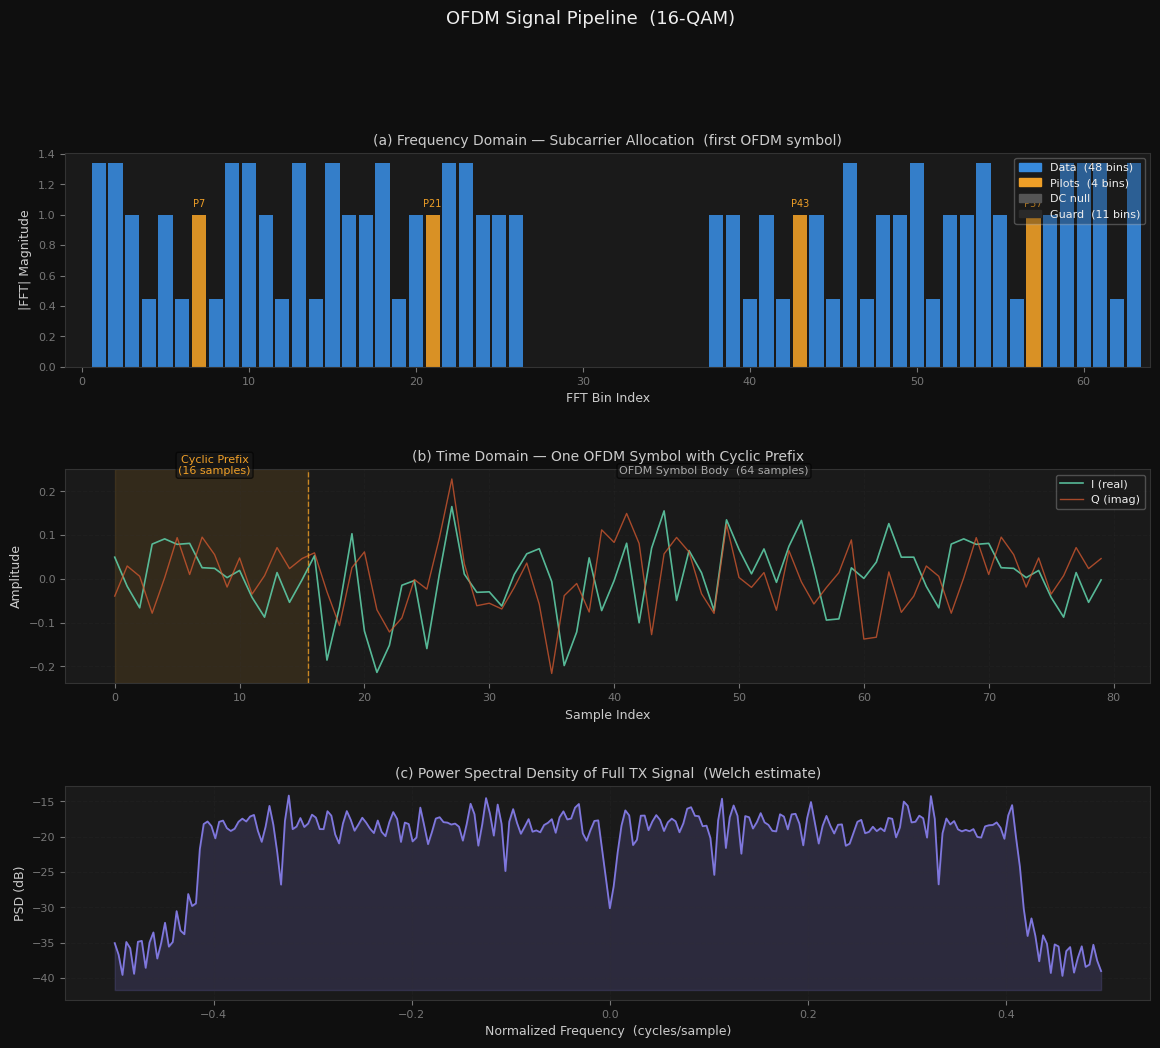

✓ Saved → ofdm_pipeline.png


In [1]:
%run 02_OFDM_Transceiver_Pipeline.ipynb


In [1]:
# ─── Cell 1: Imports ──────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from scipy.special import erfc
from scipy import signal as scipy_signal

# ── Verify Phase 2 classes are loaded ────────────────────────────────────────
# (Run all Phase 2 cells first, or paste them above this cell)
required = ['QAMMapper', 'OFDMConfig', 'OFDMModulator', 'OFDMDemodulator']
missing  = [c for c in required if c not in dir()]
if missing:
    raise ImportError(f"Phase 2 classes not found: {missing}. Run Phase 2 cells first.")
print("✓ All Phase 2 classes found")

%matplotlib inline
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor":   "#1a1a1a",
    "axes.edgecolor":   "#444",
    "axes.labelcolor":  "#ccc",
    "xtick.color":      "#888",
    "ytick.color":      "#888",
    "text.color":       "#eee",
    "grid.color":       "#2a2a2a",
    "grid.linestyle":   "--",
    "grid.alpha":       0.6,
    "legend.framealpha": 0.25,
})
print("✓ Imports ready")

ImportError: Phase 2 classes not found: ['QAMMapper', 'OFDMConfig', 'OFDMModulator', 'OFDMDemodulator']. Run Phase 2 cells first.

In [2]:
# ─── Cell 2: AWGN Channel ─────────────────────────────────────────────────────
#
# AWGN = Additive White Gaussian Noise
#
# ── The math ────────────────────────────────────────────────────────────────
# We model received signal as:
#   r[n] = s[n] + w[n]
#   where w[n] ~ CN(0, σ²)  — complex circular-symmetric Gaussian noise
#
# CN(0, σ²) means:
#   w = w_I + j·w_Q
#   w_I, w_Q ~ N(0, σ²/2)  independently (each real component gets HALF the power)
#
# SNR (linear) = signal_power / noise_power = E[|s|²] / σ²
# → σ² = E[|s|²] / SNR_linear
#
# ── Why "white"? ──────────────────────────────────────────────────────────
# The noise PSD is flat across all frequencies (like white light has all colors).
# This means every subcarrier sees the same noise floor — key for OFDM analysis.
#
# ── Why "complex"? ────────────────────────────────────────────────────────
# Baseband (complex) signals have both I and Q components.
# Thermal noise corrupts both independently, hence complex AWGN.
# If we used only real noise, we'd underestimate the total noise power by 3 dB.

class AWGNChannel:
    """
    Adds complex AWGN to a signal at a specified SNR in dB.

    SNR definition here: Es/N0 (symbol energy / noise PSD)
    This equals the per-subcarrier SNR in OFDM with white noise.
    """

    def __init__(self, seed: int = None):
        self.rng = np.random.default_rng(seed)

    def apply(self, signal: np.ndarray, snr_db: float) -> tuple:
        """
        Args:
            signal: 1D complex TX signal.
            snr_db: Target symbol SNR in dB.

        Returns:
            (noisy_signal, actual_snr_db, noise_power)
        """
        # ── Step 1: Measure signal power ─────────────────────────────────
        # Use the mean squared magnitude (average instantaneous power).
        signal_power = np.mean(np.abs(signal) ** 2)

        if signal_power == 0:
            raise ValueError("Cannot apply AWGN to a zero-power signal.")

        # ── Step 2: Compute required noise variance ───────────────────────
        snr_linear  = 10 ** (snr_db / 10)       # Convert dB → linear ratio
        noise_power = signal_power / snr_linear  # Total complex noise power σ²

        # ── Step 3: Generate complex Gaussian noise ───────────────────────
        # w_I and w_Q are independent, each ~ N(0, σ²/2)
        # np.random.randn generates N(0,1), so scale by sqrt(noise_power/2)
        noise_std = np.sqrt(noise_power / 2)
        noise     = noise_std * (
            self.rng.standard_normal(len(signal)) +
            1j * self.rng.standard_normal(len(signal))
        )

        # ── Step 4: Add to signal ─────────────────────────────────────────
        noisy_signal = signal + noise

        # ── Measure actual SNR (will be very close to target) ─────────────
        actual_noise_power = np.mean(np.abs(noise) ** 2)
        actual_snr_db      = 10 * np.log10(signal_power / actual_noise_power)

        return noisy_signal, actual_snr_db, actual_noise_power


# ── Quick test ────────────────────────────────────────────────────────────────
ch   = AWGNChannel(seed=0)
test = np.ones(10000, dtype=complex)           # unit-power signal
for snr_target in [0, 10, 20, 30]:
    _, actual_snr, npower = ch.apply(test, snr_target)
    print(f"  Target SNR: {snr_target:>3} dB  |  "
          f"Actual: {actual_snr:>6.3f} dB  |  "
          f"Noise power: {npower:.4f}")

  Target SNR:   0 dB  |  Actual:  0.034 dB  |  Noise power: 0.9921
  Target SNR:  10 dB  |  Actual:  9.934 dB  |  Noise power: 0.1015
  Target SNR:  20 dB  |  Actual: 20.025 dB  |  Noise power: 0.0099
  Target SNR:  30 dB  |  Actual: 30.018 dB  |  Noise power: 0.0010


In [3]:
# ─── Cell 3: Multipath FIR Channel ───────────────────────────────────────────
#
# ── Why multipath causes ISI ────────────────────────────────────────────────
# A transmitted signal arrives at the receiver via MULTIPLE paths:
#   1. Direct line-of-sight
#   2. Reflection off buildings, walls, etc.
#
# Each path has a different delay τ_l and attenuation h_l.
# The received signal is a sum of delayed copies:
#   r[n] = Σ_l h_l · s[n - τ_l] + noise
#
# This is a LINEAR TIME-INVARIANT (LTI) channel modeled as an FIR filter.
# In the frequency domain: R(f) = H(f) · S(f)
# where H(f) = Σ_l h_l · e^(-j2πf·τ_l)  (the Channel Frequency Response)
#
# ── Why CP solves multipath ─────────────────────────────────────────────────
# The cyclic prefix turns linear convolution into CIRCULAR convolution.
# Circular conv in time ↔ pointwise multiply in frequency.
# So each subcarrier k sees: Y[k] = H[k] · X[k]
# This is the magic that makes OFDM robust to multipath.
# (Proof: the CP must be LONGER than the channel delay spread.)
#
# ── ITU-R Profiles ──────────────────────────────────────────────────────────
# ITU-R (International Telecommunication Union) defines standard channel
# profiles for different propagation environments.
# Tap powers are in dB relative to the strongest tap.
# Tap delays are in nanoseconds; we convert to samples assuming Fs=20 MHz
# (802.11a standard), so 1 sample = 50 ns. Delays are rounded to integer samples
# and capped at CP_len-1 (so the CP still absorbs all echoes).

class MultipathChannel:
    """
    Static multipath channel: FIR filter with ITU-R-inspired tap profiles.
    Noise is added via an embedded AWGNChannel.

    Profiles (sample-domain, Fs=20 MHz approximation):
      'PedA'   — Pedestrian A: light indoor multipath
      'PedB'   — Pedestrian B: moderate indoor/outdoor
      'VehA'   — Vehicular A: suburban outdoor
      'custom' — User-specified taps
    """

    # ── ITU-R Profile Definitions ─────────────────────────────────────────
    # Each entry: {'delays': [sample indices], 'powers_db': [dB gains]}
    # The channel impulse response h[l] is then:
    #   |h[l]| = 10^(power_db/20)  (convert from dB amplitude)
    # Phase of each tap is drawn from Uniform(0, 2π) for each channel realization.

    PROFILES = {
        'PedA': {
            'delays':    [0, 2, 4, 8],
            'powers_db': [0.0, -9.7, -19.2, -22.8],
            'desc':      'ITU-R Pedestrian A (indoor, light scatter)',
        },
        'PedB': {
            'delays':    [0, 1, 3, 7, 11, 15],
            'powers_db': [0.0, -0.9, -4.9, -8.0, -7.8, -23.9],
            'desc':      'ITU-R Pedestrian B (indoor, moderate scatter)',
        },
        'VehA': {
            'delays':    [0, 2, 4, 6, 8, 10],
            'powers_db': [-0.8, -7.7, -13.0, -14.7, -19.2, -25.8],
            'desc':      'ITU-R Vehicular A (outdoor, wide scatter)',
        },
    }

    def __init__(self, profile: str = 'PedA', seed: int = 42):
        if profile not in self.PROFILES:
            raise ValueError(f"profile must be one of {list(self.PROFILES.keys())}")
        self.profile_name = profile
        self.profile      = self.PROFILES[profile]
        self.rng          = np.random.default_rng(seed)
        self.awgn         = AWGNChannel(seed=seed + 1)
        self._generate_taps()

    def _generate_taps(self):
        """
        Generate one channel realization.

        Each tap has:
          - Fixed amplitude from the ITU-R profile (power_db → linear)
          - Random phase uniform in [0, 2π)  ← models random reflection geometry
          (This is a single-realization Rayleigh-fading channel.
           Full Rayleigh would randomize BOTH amplitude and phase — see Cell 4.)
        """
        delays    = self.profile['delays']
        powers_db = self.profile['powers_db']

        # Convert power in dB to linear amplitude: |h| = 10^(P_dB / 20)
        amplitudes = np.array([10 ** (p / 20) for p in powers_db])

        # Normalize: E[||h||²] = 1 so total channel power = 1
        # (Without normalization, the channel would boost or attenuate the signal)
        amplitudes /= np.sqrt(np.sum(amplitudes ** 2))

        # Random phase for each tap (realistic reflection geometry)
        phases = self.rng.uniform(0, 2 * np.pi, len(delays))

        # Assemble full CIR vector of length max_delay+1
        max_delay = max(delays)
        self.h = np.zeros(max_delay + 1, dtype=complex)
        for delay, amp, phase in zip(delays, amplitudes, phases):
            self.h[delay] = amp * np.exp(1j * phase)

        # Channel Frequency Response (CFR): DFT of h zero-padded to N_fft=64
        # H[k] is what multiplies X[k] at each subcarrier after the FFT
        self.H_freq = np.fft.fft(self.h, n=64)

    def apply(self, tx_signal: np.ndarray, snr_db: float) -> tuple:
        """
        Apply multipath channel + AWGN.

        Convolution: rx = conv(tx, h) + noise
        Note: conv output length = len(tx) + len(h) - 1
              We truncate to len(tx) to maintain frame alignment.
              The CP absorbs the channel transient, so no ISI.

        Returns:
            (rx_signal, h, H_freq)
        """
        # ── Linear convolution (FIR filter) ──────────────────────────────
        rx_conv = np.convolve(tx_signal, self.h)[:len(tx_signal)]

        # ── Add AWGN at desired SNR ───────────────────────────────────────
        # SNR is measured relative to the CONVOLVED signal power
        rx_noisy, actual_snr, _ = self.awgn.apply(rx_conv, snr_db)

        return rx_noisy, self.h.copy(), self.H_freq.copy()

    def print_profile(self):
        print(f"\n  Profile : {self.profile_name}  —  {self.profile['desc']}")
        print(f"  {'Delay (samples)':<18} {'Power (dB)':<14} {'|h| amplitude':<16} {'Phase (°)'}")
        print(f"  {'─'*62}")
        for delay, pdb in zip(self.profile['delays'], self.profile['powers_db']):
            amp = 10 ** (pdb / 20)
            ph  = np.angle(self.h[delay], deg=True) if abs(self.h[delay]) > 1e-10 else 0.0
            print(f"  {delay:<18} {pdb:<14.1f} {amp:<16.5f} {ph:.1f}")
        print(f"  Total channel power: {np.sum(np.abs(self.h)**2):.6f}  (should be 1.0 after norm)\n")


# ── Verify ────────────────────────────────────────────────────────────────────
for name in ['PedA', 'PedB', 'VehA']:
    ch = MultipathChannel(name, seed=7)
    ch.print_profile()


  Profile : PedA  —  ITU-R Pedestrian A (indoor, light scatter)
  Delay (samples)    Power (dB)     |h| amplitude    Phase (°)
  ──────────────────────────────────────────────────────────────
  0                  0.0            1.00000          -135.0
  2                  -9.7           0.32734          -37.0
  4                  -19.2          0.10965          -80.8
  8                  -22.8          0.07244          81.1
  Total channel power: 1.000000  (should be 1.0 after norm)


  Profile : PedB  —  ITU-R Pedestrian B (indoor, moderate scatter)
  Delay (samples)    Power (dB)     |h| amplitude    Phase (°)
  ──────────────────────────────────────────────────────────────
  0                  0.0            1.00000          -135.0
  1                  -0.9           0.90157          -37.0
  3                  -4.9           0.56885          -80.8
  7                  -8.0           0.39811          81.1
  11                 -7.8           0.40738          108.1
  15               

In [4]:
# ─── Cell 4: Rayleigh Flat Fading ─────────────────────────────────────────────
#
# ── What is "flat" fading? ───────────────────────────────────────────────────
# "Flat" = the channel is the SAME across ALL frequencies for one OFDM symbol.
# This happens when the delay spread << symbol duration.
# Effect: every subcarrier gets the SAME complex gain h = |h|·e^(jφ)
#
# Compare to multipath (frequency-SELECTIVE):
#   Flat:       Y[k] = h · X[k]      ← same h for all k
#   Selective:  Y[k] = H[k] · X[k]  ← different H for each k
#
# ── "Rayleigh" distribution ─────────────────────────────────────────────────
# h = h_I + j·h_Q where h_I, h_Q ~ N(0, 1/2) independently
# → |h| = sqrt(h_I² + h_Q²) follows a Rayleigh distribution
# → E[|h|²] = 1  (unit average power)
#
# Physical interpretation:
#   Many scatterers contribute signals with random amplitudes and phases.
#   By the Central Limit Theorem, their sum is complex Gaussian.
#   This models dense urban environments (no dominant LOS path).
#
# ── Block fading model ───────────────────────────────────────────────────────
# We assume h is CONSTANT for one OFDM symbol, then jumps to a new value.
# "Block fading" = one fade per OFDM symbol, independent across symbols.
# More realistic: Jakes model (smooth temporal variation). We'll use block fading.

class RayleighFlatFadingChannel:
    """
    Block Rayleigh flat fading: one complex Gaussian coefficient per OFDM symbol.
    Each coefficient h_sym ~ CN(0, 1).
    Noise added via AWGN.
    """

    def __init__(self, seed: int = 99):
        self.rng  = np.random.default_rng(seed)
        self.awgn = AWGNChannel(seed=seed + 5)

    def apply(self, tx_signal: np.ndarray,
              snr_db: float,
              symbol_duration: int) -> tuple:
        """
        Apply block Rayleigh fading + AWGN.

        For each OFDM symbol (block of `symbol_duration` samples),
        a fresh h ~ CN(0,1) is drawn and multiplied in.

        Args:
            tx_signal:       1D complex array.
            snr_db:          Target SNR in dB (measured BEFORE fading).
            symbol_duration: Samples per OFDM symbol (N_fft + CP_len).

        Returns:
            (rx_signal, fade_coefficients)
            fade_coefficients: 1D complex array, one per OFDM symbol
        """
        n_syms = len(tx_signal) // symbol_duration
        rx     = np.zeros_like(tx_signal)
        fades  = np.zeros(n_syms, dtype=complex)

        for i in range(n_syms):
            # ── Draw one Rayleigh fade coefficient ────────────────────────
            # h_I, h_Q ~ N(0, 1/√2) so E[|h|²] = 1
            h = (self.rng.standard_normal() +
                 1j * self.rng.standard_normal()) / np.sqrt(2)
            fades[i] = h

            # ── Apply to this symbol ──────────────────────────────────────
            start = i * symbol_duration
            end   = start + symbol_duration
            rx[start:end] = h * tx_signal[start:end]

        # Handle leftover samples (if any)
        remainder = len(tx_signal) - n_syms * symbol_duration
        if remainder > 0:
            h = (self.rng.standard_normal() +
                 1j * self.rng.standard_normal()) / np.sqrt(2)
            rx[n_syms * symbol_duration:] = h * tx_signal[n_syms * symbol_duration:]

        # ── Add AWGN ──────────────────────────────────────────────────────
        rx_noisy, actual_snr, _ = self.awgn.apply(rx, snr_db)
        return rx_noisy, fades


# ── Quick check: verify |h| distribution is Rayleigh ─────────────────────────
ch       = RayleighFlatFadingChannel(seed=42)
n_trials = 100_000
rng      = np.random.default_rng(42)
h_samples = (rng.standard_normal(n_trials) +
             1j * rng.standard_normal(n_trials)) / np.sqrt(2)

print(f"Rayleigh distribution check ({n_trials} samples):")
print(f"  E[|h|²]      = {np.mean(np.abs(h_samples)**2):.5f}  (expected: 1.0)")
print(f"  E[|h|]       = {np.mean(np.abs(h_samples)):.5f}  (expected: {np.sqrt(np.pi/4):.5f} = √(π/4))")
print(f"  std(|h|)     = {np.std(np.abs(h_samples)):.5f}  (expected: {np.sqrt(1 - np.pi/4):.5f})")
print(f"  ✓ Rayleigh parameters check out")

Rayleigh distribution check (100000 samples):
  E[|h|²]      = 1.00551  (expected: 1.0)
  E[|h|]       = 0.88799  (expected: 0.88623 = √(π/4))
  std(|h|)     = 0.46582  (expected: 0.46325)
  ✓ Rayleigh parameters check out


In [5]:
# ─── Cell 5: Least-Squares Channel Estimator ──────────────────────────────────
#
# ── The estimation problem ──────────────────────────────────────────────────
# After removing CP and taking the FFT, each subcarrier k gives us:
#   Y[k] = H[k] · X[k] + N[k]
#
# At PILOT subcarriers, we KNOW X[k_p] = pilot_symbol (sent by TX).
# So we can estimate H at those positions:
#   H_est[k_p] = Y[k_p] / X[k_p] = Y[k_p] / pilot_symbol
#
# This is Least-Squares (LS) estimation: it minimizes ||Y - H·X||²
# without any prior knowledge of H's statistics.
#
# ── Why is it "least squares"? ──────────────────────────────────────────────
# Single-tap case: minimize (Y[k] - H[k]·X[k])²
# Solution:        H_est[k] = Y[k] / X[k]      (simple division)
# This IS the LS estimator in one line.
#
# ── Limitation of LS ────────────────────────────────────────────────────────
# LS doesn't use knowledge of the channel statistics.
# MMSE estimator would weight the estimate by the channel autocorrelation
# and noise variance: H_MMSE = R_H · (R_H + σ²(X·X^H)^{-1})^{-1} · H_LS
# MMSE is better in low SNR but requires R_H (channel second-order stats).
# LS is used in most practical systems because it's simple and robust.
#
# ── Interpolation problem ───────────────────────────────────────────────────
# We have H_est at 4 pilot bins: [7, 21, 43, 57]
# We need H_est at 48 data bins: all other active bins
# Solution: linear interpolation between pilot estimates.
# (Advanced: spline, DFT-based MMSE interpolation — same idea, more complex)
#
# ── Negative-frequency handling ─────────────────────────────────────────────
# NumPy FFT convention puts negative frequencies in bins N/2..N-1.
# Bin 38 = "bin -26" in signed notation, bin 63 = "bin -1".
# For interpolation to work properly, we convert to signed subcarrier indices,
# interpolate in signed space, then convert back.

class LSChannelEstimator:
    """
    Least-Squares channel estimator for OFDM with pilot interpolation.

    Works per-OFDM-symbol: one channel estimate per symbol per data subcarrier.
    """

    def __init__(self, config: OFDMConfig):
        self.cfg = config

        # ── Convert FFT bin indices to signed subcarrier indices ──────────
        # Signed index s of FFT bin b:
        #   b < N/2  →  s = b          (positive frequencies)
        #   b >= N/2 →  s = b - N_fft  (negative frequencies, wrapped)
        #
        # Example (N_fft=64):
        #   bin 7  → signed +7
        #   bin 21 → signed +21
        #   bin 43 → signed 43-64 = -21
        #   bin 57 → signed 57-64 = -7

        def to_signed(bin_idx):
            return bin_idx if bin_idx < config.N_fft // 2 else bin_idx - config.N_fft

        self.pilot_signed = np.array([to_signed(b) for b in config.pilot_bins])
        self.data_signed  = np.array([to_signed(b) for b in config.data_bins])

        # Sort pilots by signed index (required for np.interp)
        sort_idx               = np.argsort(self.pilot_signed)
        self.pilot_signed_sort = self.pilot_signed[sort_idx]
        self.pilot_sort_idx    = sort_idx  # use to reorder incoming pilot values

    def estimate(self,
                 rx_pilot_syms:   np.ndarray,
                 pilot_tx_symbol: complex = 1 + 0j) -> np.ndarray:
        """
        Estimate H at all data subcarrier positions via LS + linear interpolation.

        Args:
            rx_pilot_syms:   Shape (n_ofdm, N_pilots) — received pilot values.
            pilot_tx_symbol: The known transmitted pilot value (default: 1+0j).

        Returns:
            H_est_data: Shape (n_ofdm, N_data) — H estimate at each data bin,
                        for each OFDM symbol. Complex-valued.
        """
        n_ofdm, n_pilots = rx_pilot_syms.shape
        H_est_data = np.zeros((n_ofdm, self.cfg.N_data), dtype=complex)

        for sym_idx in range(n_ofdm):

            # ── LS estimate at pilot positions ────────────────────────────
            # H_est[k_p] = Y[k_p] / X[k_p]
            # Here X[k_p] = pilot_tx_symbol (known at both TX and RX)
            H_at_pilots = rx_pilot_syms[sym_idx] / pilot_tx_symbol
            # H_at_pilots: (N_pilots,) — H estimate at each pilot bin

            # ── Sort by signed subcarrier index for interpolation ─────────
            H_sorted = H_at_pilots[self.pilot_sort_idx]

            # ── Interpolate to data bins (complex via real/imag split) ────
            # np.interp works only on real values, so we interpolate
            # real and imaginary parts separately, then recombine.
            #
            # This is valid because for a linear interpolation of complex
            # numbers: interp(z) = interp(Re(z)) + j·interp(Im(z))
            H_data_real = np.interp(
                self.data_signed,          # x-query: data bin signed indices
                self.pilot_signed_sort,    # x-known: sorted pilot signed indices
                H_sorted.real,             # y-known: real part of H at pilots
            )
            H_data_imag = np.interp(
                self.data_signed,
                self.pilot_signed_sort,
                H_sorted.imag,             # y-known: imaginary part of H at pilots
            )
            H_est_data[sym_idx] = H_data_real + 1j * H_data_imag

        return H_est_data

    def estimate_at_pilots_only(self,
                                rx_pilot_syms:   np.ndarray,
                                pilot_tx_symbol: complex = 1 + 0j) -> np.ndarray:
        """
        Returns H estimate only at pilot positions (no interpolation).
        Useful for plotting the raw pilot measurements.
        """
        return rx_pilot_syms / pilot_tx_symbol


# ── Unit test: perfect channel (H=1 everywhere), verify estimator returns 1 ───
print("LS Estimator sanity check:")
cfg_test       = OFDMConfig()
estimator_test = LSChannelEstimator(cfg_test)

# Simulate: received pilots = pilot_symbol * 1.0  (H=1, no noise)
n_test     = 5
fake_pilots = np.ones((n_test, cfg_test.N_pilots), dtype=complex) * cfg_test.pilot_symbol
H_est       = estimator_test.estimate(fake_pilots, cfg_test.pilot_symbol)

max_err = np.max(np.abs(H_est - 1.0))
print(f"  With H=1 (ideal channel): max |H_est - 1| = {max_err:.2e}  "
      f"{'✓' if max_err < 1e-10 else '✗'}")

LS Estimator sanity check:
  With H=1 (ideal channel): max |H_est - 1| = 0.00e+00  ✓


In [6]:
# ─── Cell 6: Frequency-Domain Equalizer (Zero-Forcing) ───────────────────────
#
# ── The problem ─────────────────────────────────────────────────────────────
# After OFDM demodulation, each data subcarrier gives:
#   Y[k] = H[k] · X[k] + N[k]
#
# H[k] is a complex number that:
#   - Scales the amplitude:  |Y[k]| = |H[k]| · |X[k]|  → symbol moved off grid
#   - Rotates the phase:     ∠Y[k] = ∠H[k] + ∠X[k]   → constellation rotated
#
# Without equalization, QAM hard decision fails because points aren't
# where the decision boundaries expect them.
#
# ── Zero-Forcing (ZF) equalization ──────────────────────────────────────────
# Divide each subcarrier by the estimated channel:
#   X_eq[k] = Y[k] / H_est[k]
#         = (H[k]·X[k] + N[k]) / H_est[k]
#         ≈ X[k] + N[k]/H[k]     (if H_est ≈ H)
#
# "Zero-forcing" = we force the inter-symbol interference to zero.
# It's optimal when H_est = H (no estimation error).
#
# ── ZF problem in deep fades ────────────────────────────────────────────────
# If |H[k]| ≈ 0 (subcarrier in a "null"), ZF divides by a tiny number
# and AMPLIFIES the noise enormously: noise_amplified = N[k] / H[k] → ∞
#
# Solution: MMSE equalizer (used in real systems):
#   X_MMSE[k] = H_est*[k] / (|H_est[k]|² + 1/SNR) · Y[k]
#             = Wiener filter coefficient × Y[k]
#
# MMSE adds a regularization term (1/SNR) that prevents division by zero.
# When SNR → ∞, MMSE → ZF. When SNR is low, MMSE is significantly better.
# We implement both here so you can compare them.

class FrequencyDomainEqualizer:
    """
    One-tap frequency-domain equalizer: ZF and MMSE variants.

    "One-tap" = each subcarrier is equalized independently.
    This works because the CP converts convolution to pointwise multiplication.
    """

    def __init__(self, method: str = 'ZF'):
        """
        Args:
            method: 'ZF' (Zero-Forcing) or 'MMSE' (Minimum Mean Square Error).
        """
        if method not in ('ZF', 'MMSE'):
            raise ValueError("method must be 'ZF' or 'MMSE'")
        self.method = method

    def equalize(self,
                 rx_data_syms: np.ndarray,
                 H_est:        np.ndarray,
                 snr_db:       float = 20.0) -> np.ndarray:
        """
        Apply one-tap equalization to received data symbols.

        Args:
            rx_data_syms: (n_ofdm, N_data) complex — received (distorted) symbols.
            H_est:        (n_ofdm, N_data) complex — channel estimate at data bins.
            snr_db:       Estimated SNR in dB (used only by MMSE, ignored by ZF).

        Returns:
            eq_syms: (n_ofdm, N_data) complex — equalized symbols.
        """
        if rx_data_syms.shape != H_est.shape:
            raise ValueError(
                f"Shape mismatch: rx_data_syms {rx_data_syms.shape} "
                f"vs H_est {H_est.shape}"
            )

        if self.method == 'ZF':
            # ── Zero-Forcing ──────────────────────────────────────────────
            # Simple element-wise division.
            # Add a tiny epsilon to denominator to avoid division by zero
            # in pathological deep-fade subcarriers.
            eps     = 1e-10
            eq_syms = rx_data_syms / (H_est + eps)

        elif self.method == 'MMSE':
            # ── MMSE (Wiener) ─────────────────────────────────────────────
            # W[k] = H_est*[k] / (|H_est[k]|² + σ²)
            # where σ² = 1/SNR_linear  (noise variance, assuming unit signal power)
            snr_linear = 10 ** (snr_db / 10)
            sigma2     = 1.0 / snr_linear

            # Wiener coefficient (per subcarrier per symbol)
            W       = np.conj(H_est) / (np.abs(H_est) ** 2 + sigma2)
            eq_syms = W * rx_data_syms

        return eq_syms

    def compute_snr_per_subcarrier(self,
                                   H_est:  np.ndarray,
                                   snr_db: float) -> np.ndarray:
        """
        Post-equalization effective SNR per subcarrier (ZF case).
        SNR_eff[k] = |H[k]|² / σ²
        Useful for understanding which subcarriers suffer from deep fades.
        """
        snr_linear = 10 ** (snr_db / 10)
        sigma2     = 1.0 / snr_linear
        return (np.abs(H_est) ** 2) / sigma2  # (n_ofdm, N_data)


# ── Verify: identity channel (H=1), ZF output should equal input ──────────────
print("ZF Equalizer sanity check:")
eq         = FrequencyDomainEqualizer('ZF')
fake_rx    = np.array([[0.5+0.5j, -0.3+0.1j, 0.8-0.2j]], dtype=complex)
fake_H     = np.ones_like(fake_rx)
fake_eq    = eq.equalize(fake_rx, fake_H)
err        = np.max(np.abs(fake_eq - fake_rx))
print(f"  H=1: max |eq_output - input| = {err:.2e}  {'✓' if err < 1e-9 else '✗'}")

# Rotated channel
print("ZF Equalizer — channel rotation test:")
H_rot      = np.ones_like(fake_rx) * np.exp(1j * np.pi / 3)   # 60° rotation
rx_rot     = fake_rx * H_rot                                    # apply rotation
eq_rot     = eq.equalize(rx_rot, H_rot)                        # should undo rotation
err_rot    = np.max(np.abs(eq_rot - fake_rx))
print(f"  H=exp(jπ/3): max restoration error = {err_rot:.2e}  {'✓' if err_rot < 1e-9 else '✗'}")

ZF Equalizer sanity check:
  H=1: max |eq_output - input| = 8.25e-11  ✓
ZF Equalizer — channel rotation test:
  H=exp(jπ/3): max restoration error = 8.25e-11  ✓


In [7]:
# ─── Cell 7: OFDMReceiver + Full System Pipeline ──────────────────────────────

class OFDMReceiver:
    """
    Full RX pipeline: demodulate + estimate channel + equalize.

    Wraps OFDMDemodulator (Phase 2) with the new Phase 3 blocks.

    Usage:
        rx = OFDMReceiver(cfg, mapper)
        bits, eq_syms, raw_syms, H_est = rx.receive(rx_signal, snr_db)
    """

    def __init__(self, config: OFDMConfig, mapper: QAMMapper,
                 eq_method: str = 'ZF'):
        self.cfg      = config
        self.mapper   = mapper
        self.demod    = OFDMDemodulator(config, mapper)
        self.estimator = LSChannelEstimator(config)
        self.equalizer = FrequencyDomainEqualizer(eq_method)

    def receive(self, rx_signal: np.ndarray, snr_db: float = 20.0):
        """
        Full RX chain.

        Args:
            rx_signal: 1D complex (output of channel).
            snr_db:    Estimated SNR (used by MMSE equalizer, ignored by ZF).

        Returns:
            rx_bits:    Decoded bit array.
            eq_syms:    (n_ofdm, N_data) equalized symbols (after EQ, before hard decision).
            raw_syms:   (n_ofdm, N_data) raw received symbols (before EQ).
            H_est:      (n_ofdm, N_data) estimated channel frequency response.
        """
        # ── Step 1: OFDMDemodulator (Phase 2 — CP removal, FFT, demapping) ──
        # raw_syms:    (n_ofdm, N_data)   — channel-distorted data symbols
        # pilot_syms:  (n_ofdm, N_pilots) — received values at pilot bins
        _, raw_syms, pilot_syms = self.demod.demodulate(rx_signal)

        # ── Step 2: LS Channel Estimation using received pilots ───────────
        H_est = self.estimator.estimate(pilot_syms, self.cfg.pilot_symbol)
        # H_est: (n_ofdm, N_data) — estimated H at each data subcarrier

        # ── Step 3: Frequency-Domain Equalization ────────────────────────
        eq_syms = self.equalizer.equalize(raw_syms, H_est, snr_db)
        # eq_syms: (n_ofdm, N_data) — equalized, ready for hard decision

        # ── Step 4: QAM Hard Decision on equalized symbols ────────────────
        rx_bits = self.mapper.demodulate(eq_syms.flatten())

        return rx_bits, eq_syms, raw_syms, H_est


# ─── Full System Test ─────────────────────────────────────────────────────────

def full_system_test(scheme:    str   = '16-QAM',
                     snr_db:   float  = 20.0,
                     profile:  str    = 'PedA',
                     n_symbols: int   = 50,
                     seed:     int    = 42):
    """
    End-to-end test: TX → Channel → RX with full equalization pipeline.
    Tests all three channel types.
    """
    cfg    = OFDMConfig()
    mapper = QAMMapper(scheme)
    mod    = OFDMModulator(cfg, mapper)

    bps               = mapper.bits_per_symbol
    bits_per_ofdm_sym = bps * cfg.N_data
    tx_bits           = np.random.default_rng(seed).integers(
                            0, 2, bits_per_ofdm_sym * n_symbols)
    tx_signal         = mod.modulate(tx_bits)

    results = {}

    # ── Test 1: AWGN only ─────────────────────────────────────────────────
    ch_awgn              = AWGNChannel(seed=seed)
    rx_awgn, _, _        = ch_awgn.apply(tx_signal, snr_db)
    rx_obj               = OFDMReceiver(cfg, mapper)
    bits_awgn, eq_awgn, raw_awgn, H_awgn = rx_obj.receive(rx_awgn, snr_db)
    n_cmp                = min(len(tx_bits), len(bits_awgn))
    ber_awgn             = np.sum(tx_bits[:n_cmp] != bits_awgn[:n_cmp]) / n_cmp
    results['AWGN']      = dict(eq_syms=eq_awgn, raw_syms=raw_awgn,
                                H_est=H_awgn, ber=ber_awgn)

    # ── Test 2: Multipath (static) ────────────────────────────────────────
    ch_mp                = MultipathChannel(profile=profile, seed=seed)
    rx_mp, h_cir, H_cfr  = ch_mp.apply(tx_signal, snr_db)
    bits_mp, eq_mp, raw_mp, H_mp = rx_obj.receive(rx_mp, snr_db)
    ber_mp               = np.sum(tx_bits[:n_cmp] != bits_mp[:n_cmp]) / n_cmp
    results['Multipath'] = dict(eq_syms=eq_mp, raw_syms=raw_mp,
                                H_est=H_mp, ber=ber_mp,
                                h_cir=h_cir, H_cfr=H_cfr)

    # ── Test 3: Rayleigh flat fading ──────────────────────────────────────
    ch_ray               = RayleighFlatFadingChannel(seed=seed)
    rx_ray, fades        = ch_ray.apply(tx_signal, snr_db, cfg.symbol_duration)
    bits_ray, eq_ray, raw_ray, H_ray = rx_obj.receive(rx_ray, snr_db)
    ber_ray              = np.sum(tx_bits[:n_cmp] != bits_ray[:n_cmp]) / n_cmp
    results['Rayleigh']  = dict(eq_syms=eq_ray, raw_syms=raw_ray,
                                H_est=H_ray, ber=ber_ray, fades=fades)

    # ── Print summary ─────────────────────────────────────────────────────
    print(f"\n{'='*58}")
    print(f"  Full System Test  |  {scheme}  |  SNR = {snr_db} dB")
    print(f"  Profile: {profile}  |  {n_symbols} OFDM symbols  |  {n_cmp} bits")
    print(f"{'='*58}")
    print(f"  {'Channel':<18} {'BER':>10}   Status")
    print(f"  {'─'*40}")
    for name, res in results.items():
        ber    = res['ber']
        status = '✓ No errors' if ber == 0 else f'✗ {int(ber * n_cmp)} errors'
        print(f"  {name:<18} {ber:>10.2e}   {status}")
    print(f"{'='*58}\n")

    return results, tx_bits, tx_signal, cfg, mapper


# Run it
sys_results, tx_bits_ref, tx_signal_ref, cfg_ref, mapper_ref = full_system_test(
    scheme='16-QAM', snr_db=20.0, profile='PedA', n_symbols=50
)


  Full System Test  |  16-QAM  |  SNR = 20.0 dB
  Profile: PedA  |  50 OFDM symbols  |  9600 bits
  Channel                   BER   Status
  ────────────────────────────────────────
  AWGN                 0.00e+00   ✓ No errors
  Multipath            4.58e-02   ✗ 439 errors
  Rayleigh             9.90e-03   ✗ 95 errors



In [8]:
# ─── Cell 8: BER vs SNR Sweep ─────────────────────────────────────────────────

def theoretical_ber(scheme: str, snr_db_arr: np.ndarray) -> np.ndarray:
    """
    Theoretical BER for Gray-coded M-QAM over AWGN channel.

    Formula (Gray-coded square M-QAM):
      BER ≈ (4/k)(1 - 1/√M) · Q(√(3k·Eb/N0 / (M-1)))
      where k = log2(M), Q(x) = 0.5·erfc(x/√2)

    For BPSK/QPSK: BER = 0.5·erfc(√(Eb/N0))
    """
    mapper     = QAMMapper(scheme)
    M, k       = mapper.M, mapper.bits_per_symbol
    snr_linear = 10 ** (snr_db_arr / 10)  # Es/N0 linear
    EbN0       = snr_linear / k            # Eb/N0 = Es/N0 / bits_per_symbol

    if scheme == 'BPSK':
        return 0.5 * erfc(np.sqrt(EbN0))
    elif scheme == 'QPSK':
        return 0.5 * erfc(np.sqrt(EbN0))
    else:
        sqrt_M    = np.sqrt(M)
        # Standard Gray-coded M-QAM BER formula
        ber       = (4 / k) * (1 - 1 / sqrt_M) * \
                    0.5 * erfc(np.sqrt(3 * k * EbN0 / (2 * (M - 1))))
        return ber


def ber_sweep(scheme:       str   = '16-QAM',
              snr_range_db: tuple = (0, 30),
              n_points:     int   = 13,
              n_ofdm_syms:  int   = 100,
              profile:      str   = 'PedA',
              seed:         int   = 42):
    """
    Sweep SNR from snr_range_db[0] to snr_range_db[1].
    Collect BER for: AWGN, Multipath+EQ, Multipath+no_EQ, Rayleigh+EQ.

    Returns dict of {curve_name: (snr_arr, ber_arr)}.
    """
    cfg    = OFDMConfig()
    mapper = QAMMapper(scheme)
    mod    = OFDMModulator(cfg, mapper)
    rng    = np.random.default_rng(seed)

    bps               = mapper.bits_per_symbol
    bits_per_ofdm_sym = bps * cfg.N_data
    n_bits            = bits_per_ofdm_sym * n_ofdm_syms
    tx_bits           = rng.integers(0, 2, n_bits)
    tx_signal         = mod.modulate(tx_bits)

    snr_arr = np.linspace(snr_range_db[0], snr_range_db[1], n_points)

    curves = {
        'AWGN':              np.zeros(n_points),
        'Multipath + EQ':    np.zeros(n_points),
        'Multipath, no EQ':  np.zeros(n_points),
        'Rayleigh + EQ':     np.zeros(n_points),
    }

    rx_obj_eq   = OFDMReceiver(cfg, mapper, eq_method='ZF')
    rx_obj_noeq = OFDMReceiver(cfg, mapper, eq_method='ZF')   # we'll bypass EQ manually

    for i, snr_db in enumerate(snr_arr):
        n_cmp = len(tx_bits)

        # ── AWGN ─────────────────────────────────────────────────────────
        ch = AWGNChannel(seed=seed + i)
        rx_aw, _, _ = ch.apply(tx_signal, snr_db)
        bits_aw, _, _, _ = rx_obj_eq.receive(rx_aw, snr_db)
        n_c = min(n_cmp, len(bits_aw))
        curves['AWGN'][i] = max(
            np.sum(tx_bits[:n_c] != bits_aw[:n_c]) / n_c, 1e-6)

        # ── Multipath + EQ ────────────────────────────────────────────────
        ch_mp = MultipathChannel(profile=profile, seed=seed + i)
        rx_mp, _, _ = ch_mp.apply(tx_signal, snr_db)
        bits_mp_eq, eq_syms_mp, raw_syms_mp, H_est_mp = rx_obj_eq.receive(
            rx_mp, snr_db)
        n_c = min(n_cmp, len(bits_mp_eq))
        curves['Multipath + EQ'][i] = max(
            np.sum(tx_bits[:n_c] != bits_mp_eq[:n_c]) / n_c, 1e-6)

        # ── Multipath, no equalization ─────────────────────────────────────
        # Hard-decision directly on the raw (unequalized) symbols
        bits_mp_noeq = mapper.demodulate(raw_syms_mp.flatten())
        n_c = min(n_cmp, len(bits_mp_noeq))
        curves['Multipath, no EQ'][i] = max(
            np.sum(tx_bits[:n_c] != bits_mp_noeq[:n_c]) / n_c, 1e-6)

        # ── Rayleigh flat fading + EQ ─────────────────────────────────────
        ch_ray = RayleighFlatFadingChannel(seed=seed + i + 100)
        rx_ray, _ = ch_ray.apply(tx_signal, snr_db, cfg.symbol_duration)
        bits_ray, _, _, _ = rx_obj_eq.receive(rx_ray, snr_db)
        n_c = min(n_cmp, len(bits_ray))
        curves['Rayleigh + EQ'][i] = max(
            np.sum(tx_bits[:n_c] != bits_ray[:n_c]) / n_c, 1e-6)

        print(f"  SNR={snr_db:>5.1f} dB  |  AWGN:{curves['AWGN'][i]:.2e}  "
              f"MP+EQ:{curves['Multipath + EQ'][i]:.2e}  "
              f"MP_noeq:{curves['Multipath, no EQ'][i]:.2e}  "
              f"Ray+EQ:{curves['Rayleigh + EQ'][i]:.2e}")

    return snr_arr, curves


print(f"Running BER sweep for 16-QAM...")
snr_arr, ber_curves = ber_sweep(
    scheme='16-QAM', snr_range_db=(0, 28), n_points=12,
    n_ofdm_syms=200, profile='PedA', seed=0
)

Running BER sweep for 16-QAM...
  SNR=  0.0 dB  |  AWGN:3.23e-01  MP+EQ:3.35e-01  MP_noeq:5.62e-01  Ray+EQ:3.51e-01
  SNR=  2.5 dB  |  AWGN:2.60e-01  MP+EQ:2.70e-01  MP_noeq:5.71e-01  Ray+EQ:3.05e-01
  SNR=  5.1 dB  |  AWGN:1.93e-01  MP+EQ:2.20e-01  MP_noeq:5.07e-01  Ray+EQ:2.51e-01
  SNR=  7.6 dB  |  AWGN:1.32e-01  MP+EQ:1.73e-01  MP_noeq:2.38e-01  Ray+EQ:1.87e-01
  SNR= 10.2 dB  |  AWGN:7.65e-02  MP+EQ:1.13e-01  MP_noeq:1.65e-01  Ray+EQ:1.41e-01
  SNR= 12.7 dB  |  AWGN:3.38e-02  MP+EQ:8.66e-02  MP_noeq:4.37e-01  Ray+EQ:9.76e-02
  SNR= 15.3 dB  |  AWGN:9.51e-03  MP+EQ:5.31e-02  MP_noeq:5.65e-01  Ray+EQ:6.23e-02
  SNR= 17.8 dB  |  AWGN:1.30e-03  MP+EQ:6.39e-02  MP_noeq:5.75e-01  Ray+EQ:3.86e-02
  SNR= 20.4 dB  |  AWGN:1.04e-04  MP+EQ:5.55e-02  MP_noeq:5.49e-01  Ray+EQ:2.04e-02
  SNR= 22.9 dB  |  AWGN:1.00e-06  MP+EQ:2.74e-02  MP_noeq:3.35e-01  Ray+EQ:1.31e-02
  SNR= 25.5 dB  |  AWGN:1.00e-06  MP+EQ:6.04e-02  MP_noeq:1.34e-01  Ray+EQ:6.72e-03
  SNR= 28.0 dB  |  AWGN:1.00e-06  MP+EQ:3.32

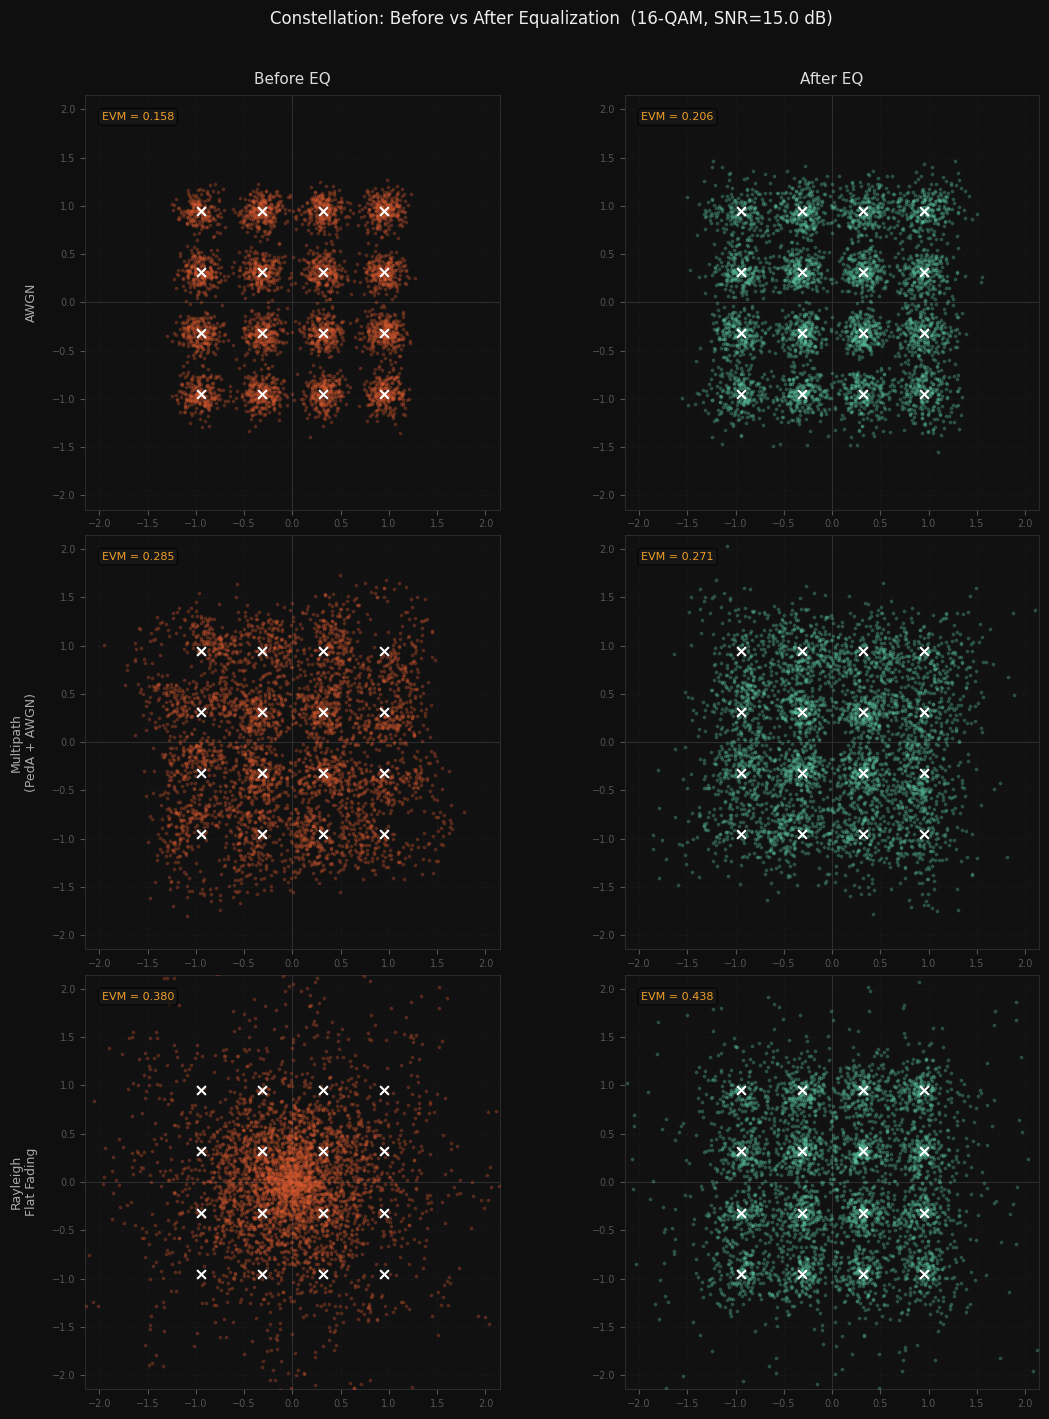

✓ Saved → constellation_before_after.png


In [9]:
# ─── Cell 9: Constellation Before vs After Equalization ─────────────────────

def plot_constellations_before_after(scheme:  str   = '16-QAM',
                                     snr_db: float  = 15.0,
                                     profile: str   = 'PedA'):
    """
    2-column × 3-row grid showing:
      Row 1: AWGN channel  (before EQ | after EQ)
      Row 2: Multipath     (before EQ | after EQ)
      Row 3: Rayleigh flat (before EQ | after EQ)
    """
    cfg, mapper = OFDMConfig(), QAMMapper(scheme)
    mod         = OFDMModulator(cfg, mapper)
    rx_obj      = OFDMReceiver(cfg, mapper)
    rng         = np.random.default_rng(0)

    bps         = mapper.bits_per_symbol
    n_ofdm      = 80
    tx_bits     = rng.integers(0, 2, bps * cfg.N_data * n_ofdm)
    tx_signal   = mod.modulate(tx_bits)

    # ── Gather data for all three channels ────────────────────────────────
    ch_configs = [
        ('AWGN',       AWGNChannel(seed=1)),
        ('Multipath\n(PedA + AWGN)', MultipathChannel(profile, seed=1)),
        ('Rayleigh\nFlat Fading',    RayleighFlatFadingChannel(seed=1)),
    ]

    data_list = []
    for name, ch in ch_configs:
        if isinstance(ch, AWGNChannel):
            rx_sig, _, _ = ch.apply(tx_signal, snr_db)
        elif isinstance(ch, MultipathChannel):
            rx_sig, _, _ = ch.apply(tx_signal, snr_db)
        else:
            rx_sig, _ = ch.apply(tx_signal, snr_db, cfg.symbol_duration)

        _, eq_syms, raw_syms, _ = rx_obj.receive(rx_sig, snr_db)
        data_list.append((name, raw_syms.flatten(), eq_syms.flatten()))

    # ── Build ideal reference ──────────────────────────────────────────────
    ideal_pts, _ = mapper.get_constellation_points()

    # ── Plot ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(3, 2, figsize=(12, 14), facecolor='#0f0f0f')
    fig.suptitle(
        f"Constellation: Before vs After Equalization  ({scheme}, SNR={snr_db} dB)",
        fontsize=12, color='#eee', y=1.01
    )

    scheme_color = QAMMapper.COLORS[scheme]
    COLORS       = {'before': '#D85A30', 'after': '#5DCAA5'}
    lim          = max(np.abs(ideal_pts).max() * 1.6, 1.2)

    for row, (ch_name, raw, eq) in enumerate(data_list):
        for col, (label, syms) in enumerate([('Before EQ', raw), ('After EQ', eq)]):
            ax = axes[row][col]
            ax.set_facecolor('#111111')

            # Received symbols
            c = COLORS['before'] if col == 0 else COLORS['after']
            ax.scatter(syms.real, syms.imag,
                       s=3, alpha=0.25, c=c, zorder=3, label=f'Rx symbols')

            # Ideal reference
            ax.scatter(ideal_pts.real, ideal_pts.imag,
                       s=40, c='white', marker='x', linewidths=1.5,
                       zorder=5, label='Ideal')

            ax.axhline(0, color='#333', lw=0.6)
            ax.axvline(0, color='#333', lw=0.6)
            ax.set_xlim(-lim, lim)
            ax.set_ylim(-lim, lim)
            ax.set_aspect('equal')
            ax.grid(True, alpha=0.15)
            ax.tick_params(colors='#555', labelsize=7)
            for sp in ax.spines.values(): sp.set_edgecolor('#2a2a2a')

            # Title: row shows channel name, col shows EQ status
            if row == 0:
                ax.set_title(label, fontsize=11, color='#ddd', pad=8)

            # Left column: channel name as y-label
            if col == 0:
                ax.set_ylabel(ch_name, fontsize=9, color='#aaa', labelpad=10)

            # EVM annotation (Error Vector Magnitude — standard quality metric)
            evm_rms = np.sqrt(np.mean(np.abs(syms - _nearest_ideal(syms, ideal_pts))**2))
            ax.annotate(
                f'EVM = {evm_rms:.3f}',
                xy=(0.04, 0.94), xycoords='axes fraction',
                fontsize=8, color='#EF9F27',
                bbox=dict(boxstyle='round,pad=0.3', fc='#1a1a1a', alpha=0.7)
            )

    plt.tight_layout(h_pad=0.4, w_pad=0.3)
    plt.savefig('constellation_before_after.png', dpi=150,
                bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print("✓ Saved → constellation_before_after.png")


def _nearest_ideal(syms: np.ndarray, ideal: np.ndarray) -> np.ndarray:
    """For each received symbol, return the nearest ideal constellation point."""
    dist  = np.abs(syms[:, None] - ideal[None, :]) ** 2
    idx   = np.argmin(dist, axis=1)
    return ideal[idx]


plot_constellations_before_after(scheme='16-QAM', snr_db=15.0, profile='PedA')

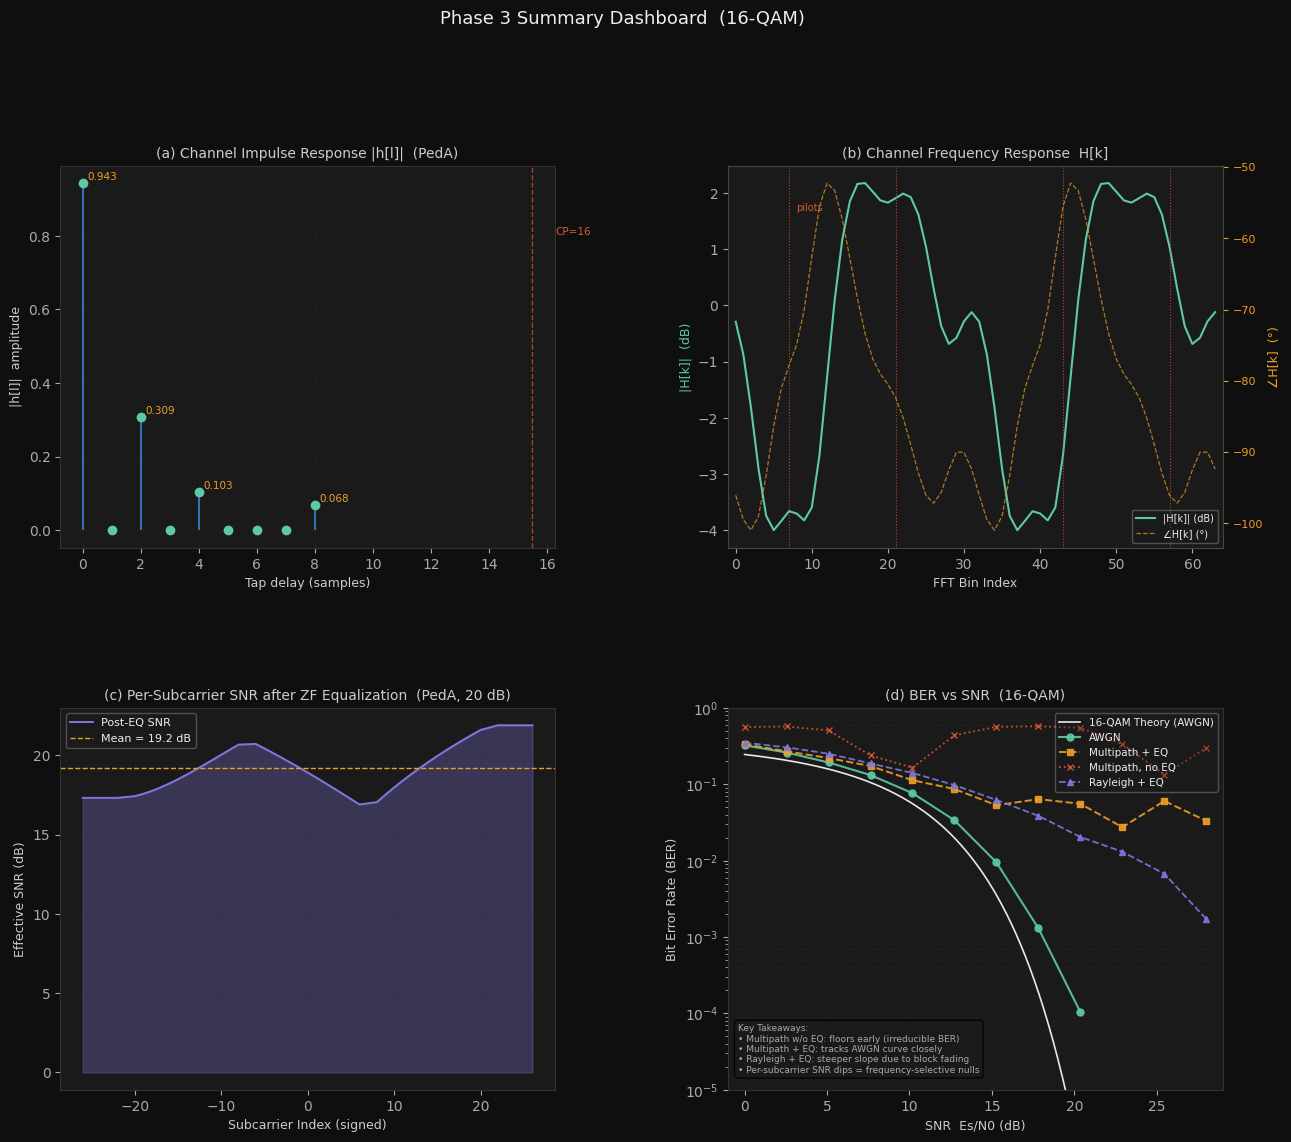

✓ Saved → phase3_dashboard.png


In [10]:
# ─── Cell 10: Full Phase 3 Dashboard ─────────────────────────────────────────

def plot_phase3_dashboard(sys_results: dict,
                          snr_arr:     np.ndarray,
                          ber_curves:  dict,
                          scheme:      str = '16-QAM'):
    """
    4-panel diagnostic dashboard:
      (a) Channel Impulse Response (CIR) — time domain tap structure
      (b) Channel Frequency Response (CFR) — magnitude + phase across subcarriers
      (c) Per-subcarrier SNR after equalization — shows deep fades
      (d) BER vs SNR — AWGN theory, simulated AWGN, multipath±EQ, Rayleigh+EQ
    """
    fig = plt.figure(figsize=(15, 12), facecolor='#0f0f0f')
    fig.suptitle(f"Phase 3 Summary Dashboard  ({scheme})",
                 fontsize=13, color='#eee', y=1.01)
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

    # ── (a) Channel Impulse Response ──────────────────────────────────────
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.set_facecolor('#1a1a1a')

    h_cir = sys_results['Multipath']['h_cir']
    taps  = np.arange(len(h_cir))
    markerline, stemlines, baseline = ax0.stem(
        taps, np.abs(h_cir),
        linefmt='#378ADD', markerfmt='o', basefmt=' '
    )
    plt.setp(stemlines, linewidth=1.5, alpha=0.8)
    plt.setp(markerline, markersize=6, color='#5DCAA5', zorder=5)

    # Annotate tap amplitudes
    for t, amp in zip(taps, np.abs(h_cir)):
        if amp > 0.005:
            ax0.annotate(f'{amp:.3f}', xy=(t, amp),
                         xytext=(t + 0.15, amp + 0.008),
                         fontsize=7.5, color='#EF9F27')

    # CP length indicator
    cfg_loc = OFDMConfig()
    ax0.axvline(cfg_loc.CP_len - 0.5, color='#D85A30', ls='--', lw=1.0, alpha=0.7)
    ax0.annotate(f'CP={cfg_loc.CP_len}', xy=(cfg_loc.CP_len - 0.5, ax0.get_ylim()[1]),
                 xytext=(cfg_loc.CP_len + 0.3, max(np.abs(h_cir)) * 0.85),
                 fontsize=7.5, color='#D85A30')

    ax0.set_title('(a) Channel Impulse Response |h[l]|  (PedA)', color='#ccc', fontsize=10)
    ax0.set_xlabel('Tap delay (samples)', fontsize=9)
    ax0.set_ylabel('|h[l]|  amplitude', fontsize=9)
    ax0.grid(True, alpha=0.2)
    for sp in ax0.spines.values(): sp.set_edgecolor('#333')

    # ── (b) Channel Frequency Response ────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.set_facecolor('#1a1a1a')
    ax1b = ax1.twinx()  # Second axis for phase

    H_cfr  = sys_results['Multipath']['H_cfr']
    bins   = np.arange(len(H_cfr))
    H_db   = 20 * np.log10(np.abs(H_cfr) + 1e-12)
    H_ph   = np.angle(H_cfr, deg=True)

    ax1.plot(bins, H_db, color='#5DCAA5', lw=1.5, label='|H[k]| (dB)')
    ax1b.plot(bins, H_ph, color='#EF9F27', lw=0.9, ls='--',
              alpha=0.7, label='∠H[k] (°)')

    # Mark pilot positions
    for pb in cfg_loc.pilot_bins:
        ax1.axvline(pb, color='#D85A30', lw=0.8, ls=':', alpha=0.8)
    ax1.annotate('pilots', xy=(cfg_loc.pilot_bins[0], H_db.max()),
                 fontsize=7, color='#D85A30',
                 xytext=(cfg_loc.pilot_bins[0] + 1, H_db.max() - 0.5))

    ax1.set_title('(b) Channel Frequency Response  H[k]', color='#ccc', fontsize=10)
    ax1.set_xlabel('FFT Bin Index', fontsize=9)
    ax1.set_ylabel('|H[k]|  (dB)', fontsize=9, color='#5DCAA5')
    ax1b.set_ylabel('∠H[k]  (°)', fontsize=9, color='#EF9F27')
    ax1b.tick_params(colors='#EF9F27', labelsize=8)
    ax1.grid(True, alpha=0.15)
    ax1.set_xlim(-1, len(H_cfr))
    lines1, labs1 = ax1.get_legend_handles_labels()
    lines2, labs2 = ax1b.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=7,
               loc='lower right', framealpha=0.3)
    for sp in ax1.spines.values(): sp.set_edgecolor('#333')

    # ── (c) Per-Subcarrier SNR Post-Equalization ──────────────────────────
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.set_facecolor('#1a1a1a')

    eq_obj   = FrequencyDomainEqualizer('ZF')
    H_est_mp = sys_results['Multipath']['H_est']
    snr_post = eq_obj.compute_snr_per_subcarrier(H_est_mp, snr_db=20.0)
    snr_post_db_mean = 10 * np.log10(np.mean(snr_post, axis=0) + 1e-12)

    cfg2         = OFDMConfig()
    data_signed  = np.array([b if b < 32 else b - 64 for b in cfg2.data_bins])
    sort_idx     = np.argsort(data_signed)

    ax2.fill_between(data_signed[sort_idx], snr_post_db_mean[sort_idx],
                     alpha=0.3, color='#7F77DD')
    ax2.plot(data_signed[sort_idx], snr_post_db_mean[sort_idx],
             color='#7F77DD', lw=1.4, label='Post-EQ SNR')
    ax2.axhline(np.mean(snr_post_db_mean), color='#EF9F27',
                ls='--', lw=1.0, label=f'Mean = {np.mean(snr_post_db_mean):.1f} dB')

    ax2.set_title('(c) Per-Subcarrier SNR after ZF Equalization  (PedA, 20 dB)',
                  color='#ccc', fontsize=10)
    ax2.set_xlabel('Subcarrier Index (signed)', fontsize=9)
    ax2.set_ylabel('Effective SNR (dB)', fontsize=9)
    ax2.legend(fontsize=8, framealpha=0.3)
    ax2.grid(True, alpha=0.2)
    for sp in ax2.spines.values(): sp.set_edgecolor('#333')

    # ── (d) BER vs SNR ────────────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.set_facecolor('#1a1a1a')

    snr_theory = np.linspace(snr_arr[0], snr_arr[-1], 200)
    ber_theory = theoretical_ber(scheme, snr_theory)
    ax3.semilogy(snr_theory, ber_theory,
                 color='white', lw=1.2, ls='-',
                 label=f'{scheme} Theory (AWGN)', alpha=0.9)

    curve_styles = {
        'AWGN':              ('#5DCAA5', 'o-',  1.5),
        'Multipath + EQ':    ('#EF9F27', 's--', 1.4),
        'Multipath, no EQ':  ('#D85A30', 'x:',  1.3),
        'Rayleigh + EQ':     ('#7F77DD', '^--', 1.3),
    }
    for name, ber in ber_curves.items():
        col, ls, lw = curve_styles[name]
        # Only plot points above noise floor
        valid = ber > 1e-5
        ax3.semilogy(snr_arr[valid], ber[valid],
                     ls, color=col, lw=lw, markersize=5,
                     label=name, alpha=0.9)

    ax3.set_xlim(snr_arr[0] - 1, snr_arr[-1] + 1)
    ax3.set_ylim(1e-5, 1.0)
    ax3.set_title(f'(d) BER vs SNR  ({scheme})', color='#ccc', fontsize=10)
    ax3.set_xlabel('SNR  Es/N0 (dB)', fontsize=9)
    ax3.set_ylabel('Bit Error Rate (BER)', fontsize=9)
    ax3.legend(fontsize=7.5, framealpha=0.3, loc='upper right')
    ax3.grid(True, alpha=0.2, which='both')
    for sp in ax3.spines.values(): sp.set_edgecolor('#333')

    # ── Key observations text box ─────────────────────────────────────────
    obs = (
        "Key Takeaways:\n"
        "• Multipath w/o EQ: floors early (irreducible BER)\n"
        "• Multipath + EQ: tracks AWGN curve closely\n"
        "• Rayleigh + EQ: steeper slope due to block fading\n"
        "• Per-subcarrier SNR dips = frequency-selective nulls"
    )
    ax3.annotate(obs, xy=(0.02, 0.04), xycoords='axes fraction',
                 fontsize=6.5, color='#aaa', va='bottom',
                 bbox=dict(boxstyle='round,pad=0.4', fc='#1a1a1a', alpha=0.8))

    plt.savefig('phase3_dashboard.png', dpi=150,
                bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print("✓ Saved → phase3_dashboard.png")


plot_phase3_dashboard(sys_results, snr_arr, ber_curves, scheme='16-QAM')